데이터 전처리

In [41]:
import pandas as pd
import numpy as np

ac_df       = pd.read_csv("adj_price (3).csv", index_col='Date', parse_dates = True)
mkt_cap_df  = pd.read_csv("market_cap (1).csv", index_col='Date', parse_dates = True)
pbr_df      = pd.read_csv("pbr (1).csv", index_col='Date', parse_dates = True)
q_roe_df    = pd.read_csv("ROE_분기 (3).csv", index_col='Date', parse_dates = True)
daily_price_df = pd.read_csv("일별수정주가 (2).csv", index_col='Date', parse_dates=True)

In [42]:
m_ret = ac_df.resample("ME").last().pct_change(fill_method= None)
m_mkt_cap = mkt_cap_df.resample("ME").last()
m_pbr = pbr_df.resample("ME").last()

m_pbr[m_pbr <=0.2] = pd.NA

In [43]:
daily_ret_df = daily_price_df.pct_change(fill_method=None)
m_max_ret = daily_ret_df.resample("ME").max()

In [44]:
m_max_ret

,삼성전자,SK하이닉스,현대차,LG에너지솔루션,SK스퀘어,삼성바이오로직스,기아,두산에너빌리티,HD현대중공업,한화에어로스페이스,...,연합과기,차이나그레이트,중국원양자원,중국식품포장,에스앤씨엔진그룹,차이나하오란,웨이포트,성융광전투자유한공사,완리,골든센츄리
Date,,,,,,,,,,,,,,,,,,,,,
2014-12-31,0.048973,0.022340,0.042254,NaN,NaN,NaN,0.034296,0.042191,NaN,0.030738,...,NaN,0.150160,0.149582,NaN,0.149773,0.149731,0.149677,NaN,0.149789,NaN
2015-01-31,0.021593,0.053797,0.047059,NaN,NaN,NaN,0.022989,0.034417,NaN,0.084066,...,NaN,0.148511,0.148558,NaN,0.039652,0.103298,0.110294,NaN,0.085556,NaN
2015-02-28,0.016764,0.037652,0.028481,NaN,NaN,NaN,0.018100,0.057751,NaN,0.048328,...,NaN,0.046679,0.149436,NaN,0.053450,0.050528,0.149860,NaN,0.082923,NaN
2015-03-31,0.048637,0.038549,0.037037,NaN,NaN,NaN,0.027115,0.051802,NaN,0.050023,...,NaN,0.028625,0.036870,NaN,0.020246,0.075345,0.147619,NaN,0.056482,NaN
2015-04-30,0.025105,0.040573,0.037152,NaN,NaN,NaN,0.045606,0.051678,NaN,0.091051,...,NaN,0.033926,0.045455,NaN,0.149925,0.148814,0.112773,NaN,0.111713,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-31,0.060674,0.098611,0.094340,0.148201,0.158151,0.097371,0.072254,0.149691,0.099609,0.044956,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-30,0.042487,0.109123,0.024621,0.053204,0.086538,0.014751,0.032698,0.059949,0.059701,0.064351,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-31,0.053105,0.068447,0.111111,0.059859,0.084337,0.047281,0.041852,0.045333,0.062615,0.090805,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
lagged_roe  = q_roe_df.shift(4)
monthly_roe = lagged_roe.reindex(m_pbr.index).ffill()

In [46]:
month_ends  = ac_df.resample('ME').last().loc['2015-03-31':'2025-12-31'].index


portfolio_ret                = pd.Series(dtype=float)
portfolio_ret[month_ends[0]] = 0.0

low pbr + high roe

In [47]:
for i in range(len(month_ends) - 1):
    start_date  = month_ends[i]
    end_date    = month_ends[i+1]
    
    # 해당 시점의 데이터 추출
    pbr_now     = m_pbr.loc[start_date]
    mkt_cap_now = m_mkt_cap.loc[start_date].reindex(pbr_now.index)
    roe_now     = monthly_roe.loc[start_date].reindex(pbr_now.index)
    max_ret_now = m_max_ret.loc[start_date].reindex(pbr_now.index)
    
    # STEP 1: 소형주 필터링 (시가총액 하위 50%)
    small_cap_threshold = mkt_cap_now.median()
    small_cap_mask      = mkt_cap_now <= small_cap_threshold
    lottery_threshold = max_ret_now[small_cap_mask].quantile(0.90)
    non_lottery_mask = max_ret_now <= lottery_threshold
    final_universe_mask = small_cap_mask & non_lottery_mask

    # STEP 2: 순위 계산 (소형주 내에서)
    # PBR은 낮을수록 좋으므로 오름차순 순위
    pbr_rank = pbr_now[final_universe_mask].rank(ascending=True)
    
    # ROE는 높을수록 좋으므로 내림차순 순위
    roe_rank = roe_now[final_universe_mask].rank(ascending=False)
 
    
    # STEP 3: 통합 순위 생성 및 상위 20개 종목 선정
    # 두 순위의 합이 가장 작은(우수한) 종목 선택
    total_rank      = pbr_rank + roe_rank
    final_selection = total_rank.nsmallest(20).index
    print(final_selection)
    # STEP 4: 수익률 계산 (동일 가중)
    if not final_selection.empty:
        # 다음 한 달 동안의 수익률 평균
        daily_ret                   = m_ret.loc[end_date].reindex(final_selection)
        portfolio_ret.loc[end_date] = daily_ret.mean()


Index(['엘앤에프', '에스피지', '에스앤에스텍', '쎄트렉아이', '오스코텍', '신성델타테크', '코스모신소재', '성호전자',
       '제주반도체', '대주전자재료', '제이에스링크', '피엔티', 'SK오션플랜트', '에프에스티', '제룡전기', '비나텍',
       '포스코엠텍', '로보스타', '대한광통신', '우리기술투자'],
      dtype='object')
Index(['이엠앤아이', '에스엠화진(주)', 'KS인더스트리', '진도', '오스템', '삼진', '제일테크노스', '코스나인',
       '프로텍', 'NICE인프라', '코메론', '대창단조', '삼보모터스', '성도이엔지', '서연탑메탈', '인팩',
       '고려산업', '코다코', '성우전자', 'CS홀딩스'],
      dtype='object')
Index(['이엠앤아이', '에스엠화진(주)', 'KS인더스트리', '우신시스템', '오스템', '제일테크노스', 'CS홀딩스', '인팩',
       '모베이스', '성도이엔지', 'SJM홀딩스', 'KCTC', '코스나인', '코다코', '한국석유', '삼진', '프로텍',
       '원일특강', '대창단조', 'NICE인프라'],
      dtype='object')
Index(['이엠앤아이', 'KS인더스트리', '우신시스템', '한국공항', '진도', '오스템', '제일테크노스', 'CS홀딩스',
       '인팩', 'YTN', 'KCTC', '모베이스', '삼보모터스', '성도이엔지', '모베이스전자', '유니퀘스트',
       '지엠비코리아', '엘엠에스', '프로텍', 'SJM홀딩스'],
      dtype='object')
Index(['이엠앤아이', '에스엠화진(주)', 'KS인더스트리', '파인테크닉스', '우신시스템', '한국공항', '진도', '오스템',
       'CS홀딩스', '인팩', '제일테크노스', 'YTN', '삼보모터스', 'SJM홀딩스', '

성과지표 및 NAV 확인

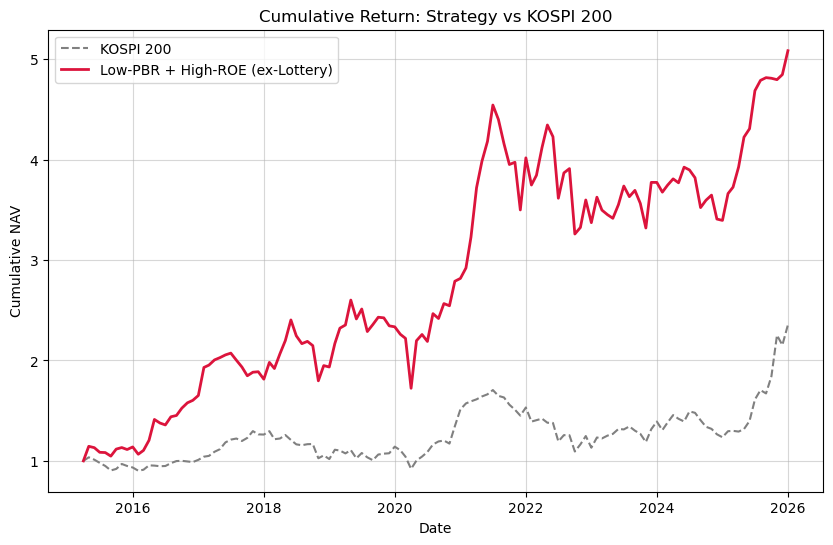

In [48]:
import matplotlib.pyplot as plt

# 1. 내 전략의 누적 수익률 계산 (시작점 1.0)
cum_ret = (1 + portfolio_ret.fillna(0)).cumprod()

# 2. KOSPI 200 데이터 불러오기 및 세팅
ks200_df = pd.read_csv("KOSPI200 (2).csv", index_col=0, parse_dates=True)
ks200_df.index = pd.to_datetime(ks200_df.index)

# 내 포트폴리오의 날짜(월말)에 맞춰서 KOSPI 200 데이터 추출
ks200_monthly = ks200_df.resample('ME').last().loc[cum_ret.index]

# KOSPI 200도 내 전략과 똑같이 첫 날을 1.0으로 기준점을 맞춰줍니다.
ks200_cum_ret = ks200_monthly / ks200_monthly.iloc[0]

# 3. 그래프 시각화
plt.figure(figsize=(10, 6))

# KOSPI 200은 회색 점선
plt.plot(ks200_cum_ret.iloc[:, 0], label='KOSPI 200', color='gray', linestyle='--')

# 눈에 띄는 색상과 굵은 선으로 강조
plt.plot(cum_ret, label='Low-PBR + High-ROE (ex-Lottery)', color='crimson', linewidth=2)

plt.title('Cumulative Return: Strategy vs KOSPI 200')
plt.xlabel('Date')
plt.ylabel('Cumulative NAV')
plt.legend()
plt.grid(True, alpha=0.5) # 보기 편하게 격자 추가
plt.show()

In [49]:
years = (cum_ret.index[-1] - cum_ret.index[0]).days / 365.25
cagr  = (cum_ret.iloc[-1] / cum_ret.iloc[0]) ** (1 / years) - 1
print(f"CAGR: {cagr:.2%}")

CAGR: 16.33%


In [50]:
vol   = portfolio_ret.std()*np.sqrt(12)
print(f"Volatility: {vol:.2%}")

Volatility: 23.90%


In [51]:
# Sharpe Ratio 계산
risk_free_rate = (1 + 0.02) ** (1/12) - 1  # 무위험 수익률 월율화 (예: 연 2%)
excess_returns = portfolio_ret - risk_free_rate
sharpe_ratio   = excess_returns.mean() / excess_returns.std() * np.sqrt(12)  # 연율화
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

Sharpe Ratio: 0.67


In [52]:
drawdown = cum_ret / cum_ret.cummax() - 1
mdd = drawdown.min()
print(f"MDD: {mdd:.2%}")

MDD: -33.76%


In [53]:
factors_raw         = pd.read_csv("/Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/고배당전략/input/Factor.csv", index_col =0, parse_dates=True)
factors           = factors_raw.resample("ME").last()

In [54]:
import statsmodels.api as sm

def make_ff_factors(factors, freq="D", annual_rf=True):
    """
    factors: DataFrame with columns ['KOSPI','SMB','HML','MOM','RF']
    freq: 'D' (일간) 또는 'M' (월간)
    """
    
    df = factors.copy()

    # 0. resampling
    if freq == "M":
        df = df.resample('ME').last()
    
    # 1. 지수 → 수익률 변환
    ret_cols = ['KOSPI','SMB','HML','MOM']
    df[ret_cols] = df[ret_cols].pct_change()
    
    # 2. 무위험금리 변환 (연율 → 일/월 수익률)
    df['RF'] = df['RF'] / 100  # % → 소수화 (예: 3.5% → 0.035)
    
    if freq == "D":
        trading_days = 252
        df['RF'] = (1 + df['RF']) ** (1/trading_days) - 1
    elif freq == "M":
        df['RF'] = (1 + df['RF']) ** (1/12) - 1
    
    # 4. 컬럼 정리
    df = df[['KOSPI','SMB','HML','MOM','RF']].dropna()
    
    return df

In [55]:
ff_monthly = make_ff_factors(factors, freq="M")

In [56]:
# portfolio_ret = cap_portfolio_ret
port_ret = portfolio_ret
port_ret.name = "Portfolio"

# 1. 두 데이터 공통 구간 맞추기
df = pd.concat([port_ret, ff_monthly], axis=1, join="inner").dropna()

# 2. 종속변수: 포트폴리오 초과수익률
y = df[port_ret.name] - df['RF']

# 3. 독립변수: MKT, SMB, HML, MOM
X = pd.DataFrame({
    "MKT": df['KOSPI'] - df['RF'],
    "SMB": df['SMB'],
    "HML": df['HML'],
    "MOM": df['MOM']
}, index=df.index)

X = sm.add_constant(X, has_constant='add')

# 4. OLS 회귀
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":12})  # Newey-West 표준오차
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.691
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     110.7
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           4.06e-40
Time:                        15:46:51   Log-Likelihood:                 239.86
No. Observations:                 130   AIC:                            -469.7
Df Residuals:                     125   BIC:                            -455.4
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0077      0.002      3.386      0.0